# DFT diagnostic MCMC (refloxide)

Loads pickled DFT and free-tensor fits, builds a **single-energy 283.7 eV** objective with the Rust refloxide reflectivity kernel, and runs emcee for structure uncertainties.

The old multi-energy `GlobalObjective` path duplicated parameters (31 walkers dimensions) and evaluated stock pyref reflectivity on every energy each step (~27 s/emcee iteration). This notebook uses `build_dft_diagnostic_pyref_mcmc_objective` (~5 ms/logl, 13 DOF).

For multi-energy **refits**, use `fit_dft_refloxide.ipynb` (`BatchedGlobalObjective` + shared `DispersiveStructure`).


In [1]:
import time

import matplotlib.pyplot as plt

from utils import (
    build_dft_diagnostic_pyref_mcmc_objective,
    read_fit,
    read_ooc,
)
from utils.helpers.plotting_helper import set_plotting_defaults
from utils.models import CurveFitter, configure_refloxide_fitting

configure_refloxide_fitting(use_rust=True, parallel=False)

plt.style.use(["science", "no-latex"])
set_plotting_defaults()

In [2]:
dft_constrained = read_fit("dft/dft_en_offset_new2.pkl", material="znpc")
free = read_fit("free/free_en_offset_init_2.pkl", material="znpc")
oocs = read_ooc("dft.csv", material="znpc")

In [3]:
mcmc_obj = build_dft_diagnostic_pyref_mcmc_objective(
    dft_constrained,
    oocs,
    free_bundle=free,
)
mcmc_obj.logl()


np.float64(-3.8915599401446594)

In [4]:
mcmc_obj.varying_parameters()

Parameters(data=[Parameter(value=8.933505699132835, name='Surface_283.7_thick', vary=True, bounds=Interval(lb=0.0, ub=35.0), constraint=None), Parameter(value=7.056021690245074, name='Surface_283.7_rough', vary=True, bounds=Interval(lb=0.0, ub=25.0), constraint=None), Parameter(value=1.8, name='Surface_283.7_density', vary=True, bounds=Interval(lb=1.0, ub=1.8), constraint=None), Parameter(value=0.9111972745709315, name='Surface_283.7_rotation', vary=True, bounds=Interval(lb=0.0, ub=1.5707963267948966), constraint=None), Parameter(value=179.9514730957673, name='ZnPc_283.7_thick', vary=True, bounds=Interval(lb=160.0, ub=200.0), constraint=None), Parameter(value=13.136336626059903, name='ZnPc_283.7_rough', vary=True, bounds=Interval(lb=0.0, ub=25.0), constraint=None), Parameter(value=1.6385167795334732, name='ZnPc_283.7_density', vary=True, bounds=Interval(lb=1.2, ub=1.8), constraint=None), Parameter(value=1.2136777574521447, name='ZnPc_283.7_rotation', vary=True, bounds=Interval(lb=0.0, 

In [5]:
print(len(mcmc_obj.varying_parameters()))

t0 = time.perf_counter()
for _ in range(20):
    mcmc_obj.logl()
print(f"logl: {(time.perf_counter() - t0) / 20 * 1e3:.1f} ms")

13
logl: 8.1 ms


In [6]:
quick_fit = CurveFitter(mcmc_obj, walkers_per_param=10)

In [7]:
quick_fit.initialise(pos="jitter", random_state=0)
quick_fit.sample(100, pool=1, skip_check=True)

100%|██████████| 100/100 [00:53<00:00,  1.89it/s]


[MCMCResult(name='Surface_283.7_thick', param=Parameter(value=8.933546913914046, name='Surface_283.7_thick', vary=True, bounds=Interval(lb=0.0, ub=35.0), constraint=None), stderr=0.010872444857981556, chain=array([[8.93508162, 8.9336144 , 8.93354658, ..., 8.93331793, 8.93270179,
         8.93440451],
        [8.93683316, 8.9336144 , 8.93354658, ..., 8.93358787, 8.93270179,
         8.9343414 ],
        [8.93683316, 8.9336144 , 8.93368455, ..., 8.93358787, 8.93270179,
         8.9343414 ],
        ...,
        [9.84433624, 8.94388924, 8.94771366, ..., 8.94535441, 8.91849128,
         9.33696868],
        [9.84433624, 8.94388924, 8.94771366, ..., 8.94535441, 8.91849128,
         9.33696868],
        [9.84433624, 8.94388039, 8.94771366, ..., 8.94535441, 8.91849128,
         9.33696868]], shape=(100, 200)), median=np.float64(8.933546913914046)),
 MCMCResult(name='Surface_283.7_rough', param=Parameter(value=7.055924193206863, name='Surface_283.7_rough', vary=True, bounds=Interval(lb=0.0, ub

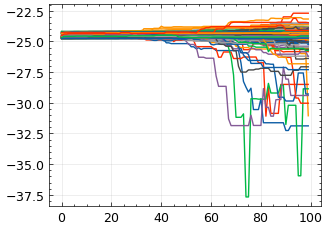

In [10]:
import matplotlib.pyplot as plt

fig = plt.plot(quick_fit.logpost)

(<Axes: ylabel='Reflectivity'>,
 <Axes: xlabel='$q (\\AA^{-1})$', ylabel='Anisotropy'>)

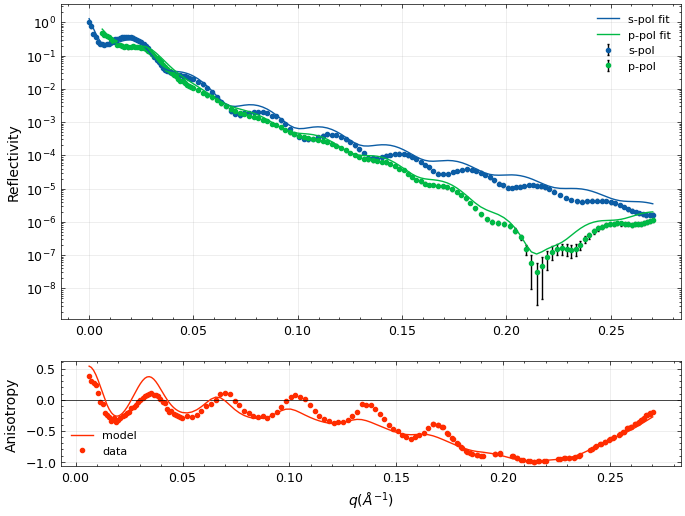

In [14]:
obj = quick_fit.objective
obj.plot()